# Finding Similar Items in arXiv Abstracts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/paolominini/lsh-abstract-similarity/blob/main/similarity.ipynb)

Detects pairs of highly similar paper abstracts from the
[arXiv dataset](https://www.kaggle.com/datasets/Cornell-University/arxiv)


## 0. Setup

In [1]:
import os
import re
import json
import time
import zlib
import random
import zipfile
import itertools
import unicodedata
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


try:
    import psutil
    _PROC = psutil.Process(os.getpid())
except Exception:
    psutil, _PROC = None, None

SEED = 42

DATASET   = "Cornell-University/arxiv"
JSON_FILE = "arxiv-metadata-oai-snapshot.json"
MEMMAP_PATH = "signatures.dat" # to save the signatures

USE_WHOLE_DATA = True
SUBSAMPLE_SIZE = 500_000
MIN_ABSTRACT_WORDS = 20   # drop abstracts shorter than this (withdrawal notices, placeholders)

# parameters used in the project
SHINGLE_K   = 3
N_HASHES    = 100
BANDS, ROWS = 20, 5
PRIME       = 4_294_967_291
BATCH_SIZE  = 2_000
THRESHOLD   = (1 / BANDS) ** (1 / ROWS)

assert BANDS * ROWS == N_HASHES, "BANDS * ROWS must equal N_HASHES"

# samples for evaluation
PRECISION_SAMPLE = 1_000


print(f"NumPy {np.__version__} | cores {os.cpu_count()} | seed {SEED}")
print("FULL DATASET" if USE_WHOLE_DATA else f"SUBSAMPLE: {SUBSAMPLE_SIZE:,} docs")
print(f"signature {N_HASHES} = {BANDS} bands x {ROWS} rows | threshold t = {THRESHOLD:.3f}")


NumPy 2.0.2 | cores 2 | seed 42
FULL DATASET
signature 100 = 20 bands x 5 rows | threshold t = 0.549


## 1. Data Ingestion

In [2]:
os.environ["KAGGLE_USERNAME"] = "XXXXXXX"
os.environ["KAGGLE_KEY"]      = "XXXXXXX"

!pip install -q kaggle
!kaggle datasets download -d {DATASET}

with zipfile.ZipFile("arxiv.zip") as z:
    z.extract(JSON_FILE)


Dataset URL: https://www.kaggle.com/datasets/Cornell-University/arxiv
License(s): CC0-1.0
arxiv.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
def load_abstracts(path, limit=None, min_words=MIN_ABSTRACT_WORDS):
    ids, abstracts = [], []
    n_seen, n_kept = 0, 0
    with open(path, encoding="utf-8") as f:
        # Instead of using pd.read_json() we iterate through the file line-by-line
        for line in f:
            if limit is not None and n_seen >= limit:
                break
            n_seen += 1
            rec = json.loads(line)
            abstract = rec["abstract"]
            if len(abstract.split()) < min_words:
                # drop withdrawal notices / stubs one string at a time here, instead of
                # running .str.split() over the whole column afterwards (that's what OOM'd)
                continue
            ids.append(rec["id"])
            abstracts.append(abstract)
            n_kept += 1
    print(f"scanned {n_seen:,} lines, kept {n_kept:,} abstracts (dropped {n_seen - n_kept:,} too short)")
    return pd.DataFrame({"id": ids, "abstract": abstracts})


limit = None if USE_WHOLE_DATA else SUBSAMPLE_SIZE
df = load_abstracts(JSON_FILE, limit=limit)
df.head(3)

scanned 3,080,258 lines, kept 3,064,847 abstracts (dropped 15,411 too short)


,id,abstract
0,0704.0001,A fully differential calculation in perturba...
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-..."
2,0704.0003,The evolution of Earth-Moon system is descri...


## 2. Text Normalization

Turn each raw abstract into a clean list of word tokens: strip LaTeX  math and commands, drop punctuation, transform all test into lowercase, and collapse whitespace.
The result is a list of "cleaned" tokens of the document (the abstract).

In [4]:
_MATH = re.compile(r"\$[^$]*\$")  # anything between $ signs
_CMD  = re.compile(r"\\[a-zA-Z]+") # LaTeX commands
_KEEP = re.compile(r"[^a-z0-9\s]+") # any character that is NOT a letter, number, or space
_WS   = re.compile(r"\s+") # any sequence of whitespace

def normalize(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode().lower()
    # NFKD decomposes complex Unicode characters
    # and stripping non-ASCII characters to ensure a uniform vocabulary for shingling.
    text = _MATH.sub(" ", text)
    text = _CMD.sub(" ", text)
    text = _KEEP.sub(" ", text)
    return _WS.sub(" ", text).strip().split()

# Demo Example of how normalization works
sample = df["abstract"].iloc[0]

print("Example of a RAW vs NORMALIZED (in tokens) abstract")
print("-"*50)
print("RAW ABSTRACT:    ", sample[:200].replace("\n", " "), "...")
print("NORMALIZED TOKENS:", normalize(sample)[:25])

Example of a RAW vs NORMALIZED (in tokens) abstract
--------------------------------------------------
RAW ABSTRACT:       A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. All next-to-leading order perturbative contributi ...
NORMALIZED TOKENS: ['a', 'fully', 'differential', 'calculation', 'in', 'perturbative', 'quantum', 'chromodynamics', 'is', 'presented', 'for', 'the', 'production', 'of', 'massive', 'photon', 'pairs', 'at', 'hadron', 'colliders', 'all', 'next', 'to', 'leading', 'order']


## 3. Word Shingling and Hashing

We slide the shingle "window" (of dimension 3 words in our case) over the normalized and tokenized abstract, we retrieve the shingles (unique cases using a set instead of a list) and convert those into integers using the hash function (zlib.crc323).

The result is an array containing the integers referring to the shingles in the abstract.


In [5]:
def shingle_hashes(tokens, k=SHINGLE_K):
    if len(tokens) < k:
        return np.empty(0, dtype=np.uint32)
    shingles = {
        zlib.crc32(" ".join(tokens[i:i + k]).encode())
         # sliding window putting together 3 tokens, encoded and then put in hash function
        for i in range(len(tokens) - k + 1)
    }
    return np.fromiter(shingles, dtype=np.uint32, count=len(shingles))
            # builds a numpy array efficiently (avoiding to turn to list the iterable)

# Demo Example of how shingling + hashing works
demo = normalize(df["abstract"].iloc[0])
hashes = shingle_hashes(demo)

print("Example of a Word Shingling hashed")
print("-"*50)
print(f"{len(demo)} tokens -> transformed into {len(hashes)} unique {SHINGLE_K}-word shingles")
print("Example of the first 8 hashed shingles of an abstract: ",hashes[:5])

Example of a Word Shingling hashed
--------------------------------------------------
152 tokens -> transformed into 149 unique 3-word shingles
Example of the first 8 hashed shingles of an abstract:  [3529172992 1300697089  860221952 3033757184  727469057]


## 4. Vectorized MinHash

We draw random hash functions and compress each document's
shingle set into signature. We keep the minimum hash over the document's shingles.

Documents are processed in batches. A batch's shingles are flattened into a single array, hashed in one matrix operation.

Signatures are written straight to the disk using memmap.

In [6]:
# Initializing random hash functions
_rng = np.random.default_rng(SEED)
A = _rng.integers(1, PRIME, size=N_HASHES, dtype=np.uint64)
B = _rng.integers(0, PRIME, size=N_HASHES, dtype=np.uint64)


def minhash_batch(shingle_arrays): # shingle_arrays will be a batch of the documents (abstracts) not the entire dataset
    n = len(shingle_arrays)
    # signature matrix initialization
    sig = np.full((n, N_HASHES), 0xFFFFFFFF, dtype=np.uint32)
    # how many shingles does each doc have
    lengths = np.fromiter((len(s) for s in shingle_arrays), dtype=np.intp, count=n)
    # the indeces of each non-zero length doc
    keep = np.flatnonzero(lengths)
    if keep.size == 0:
        return sig
    # instead of iterating over documents we flatten the shingles in a 1D array
    flat = np.concatenate([shingle_arrays[i] for i in keep]).astype(np.uint64)
    starts = np.zeros(keep.size, dtype=np.intp)
    np.cumsum(lengths[keep][:-1], out=starts[1:]) # the length of each doc indicates where it ends and where the new one begins
    H = (A[:, None] * flat[None, :] + B[:, None]) % PRIME
    # H.shape is now (N_HASHES, total_shingles)
    # we group it in the actual documents over total_shingles by using starts (index of where each doc begin)
    # it then finds the minimum for each document across the hash function
    sig[keep] = np.minimum.reduceat(H, starts, axis=1).T.astype(np.uint32)
    return sig

In [7]:
def build_signatures(frame):
    num_docs = len(frame)
    sig = np.memmap(MEMMAP_PATH, dtype=np.uint32, mode="w+", shape=(num_docs, N_HASHES))
    abstracts = frame["abstract"].to_numpy()
    for start in tqdm(range(0, num_docs, BATCH_SIZE), desc="MinHashing (per batch computation)"):
        end = min(start + BATCH_SIZE, num_docs)
        batch = [shingle_hashes(normalize(abstracts[j])) for j in range(start, end)]
        sig[start:end] = minhash_batch(batch)
    sig.flush()
    return sig

t0 = time.time()
signatures = build_signatures(df)
t_minhash_full = time.time() - t0
print(f"signatures: {signatures.shape} in {t_minhash_full:.1f}s")

MinHashing (per batch computation):   0%|          | 0/1533 [00:00<?, ?it/s]

signatures: (3064847, 100) in 1702.4s


## 5. LSH Banding

We compare signatures within the same BAND having a certain amount of ROWS.
If two documents share an identical chunk in the same band, they land in the same bucket and become a candidate pair.

In this way pairs more similar than t (= (1/b)^(1/r)) are more likely to fall in the same bucket, becoming candidates


In [8]:
def lsh_candidates(sig):
    num_docs = sig.shape[0]
    candidates = set()
    for band in tqdm(range(BANDS), desc="LSH (per band computation)        "):
        start = band * ROWS
        block = np.ascontiguousarray(sig[:, start:start + ROWS])
        # block has now shape (num_docs, ROWS)
        buckets = defaultdict(list) # each item is stored in a list
        for doc in range(num_docs):
            # if documents share the same signature (which is the key) they are put in the same list
            buckets[block[doc].tobytes()].append(doc)
        for docs in buckets.values():
            if len(docs) > 1: # only if two docs fall within the same list
                candidates.update(itertools.combinations(docs, 2))
                # itertools.combinations returns all unique pairs of candidates
                # ex. (doc1,doc2,doc3) -> (doc1,doc2), (doc1,doc3), (doc2,doc3)
    return candidates

t0 = time.time()
candidate_pairs = lsh_candidates(signatures)
t_lsh_full = time.time() - t0
print(f"{len(candidate_pairs):,} candidate pairs in {t_lsh_full:.1f}s")

LSH (per band computation)        :   0%|          | 0/20 [00:00<?, ?it/s]

19,875 candidate pairs in 156.1s


## 6. Validation

We evaluate the results using Precision:

How many pairs found with LSH are actually similar docs?
It's computed comparing actual Jaccard Similarity across shingles hashes (for a small sample of actual candidates retrieved by LSH).


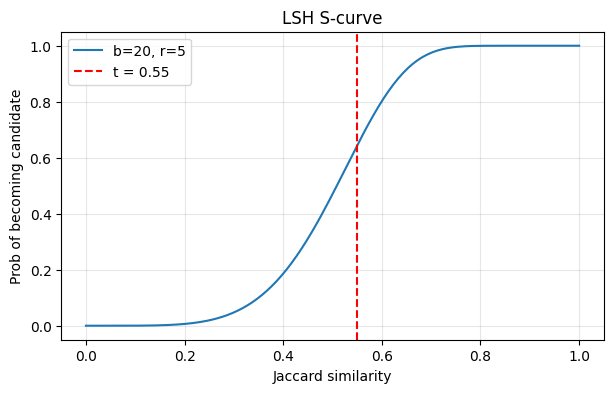

In [9]:
def doc_shingle_set(text):
    return set(shingle_hashes(normalize(text)).tolist())
    # creates sets of shingle-hashes for a doc

def true_jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


def evaluate_precision(pairs, abstracts, sample_size=PRECISION_SAMPLE, seed=SEED):
    pairs = list(pairs) # actual candidate pairs found with LSH
    if not pairs:
        return float("nan"), np.empty(0)
    sample = random.Random(seed).sample(pairs, min(sample_size, len(pairs)))
    # local Random instance: same sample every time this runs, regardless of how many
    # times the global random module has already been drawn from in this session
    cache, sims = {}, []
    for i, j in sample:
        si = cache.setdefault(i, doc_shingle_set(abstracts[i]))
        sj = cache.setdefault(j, doc_shingle_set(abstracts[j]))
        sims.append(true_jaccard(si, sj))
    sims = np.array(sims)
    return float(np.mean(sims >= THRESHOLD)), sims


def plot_scurve():
    s = np.linspace(0, 1, 200)
    p = 1 - (1 - s ** ROWS) ** BANDS
    plt.figure(figsize=(7, 4))
    plt.plot(s, p, label=f"b={BANDS}, r={ROWS}")
    plt.axvline(THRESHOLD, color="r", ls="--", label=f"t = {THRESHOLD:.2f}")
    plt.xlabel("Jaccard similarity")
    plt.ylabel("Prob of becoming candidate")
    plt.title("LSH S-curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_scurve()

========== Results over FULL DATASET ==========
   Precision (sampled 1000 candidates): 62.6%


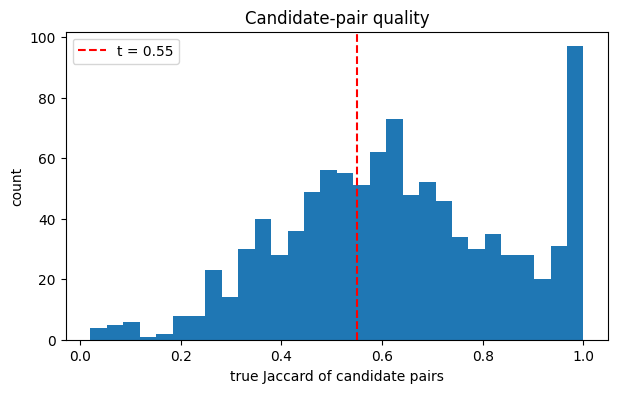

In [10]:
abstracts = df["abstract"].to_numpy()

label = "FULL DATASET" if USE_WHOLE_DATA else "SUBSAMPLE DATA"
print("="*10, f"Results over {label}", "="*10)
prec, sims = evaluate_precision(candidate_pairs, abstracts)
print(f"   Precision (sampled {len(sims)} candidates): {prec:.1%}")

plt.figure(figsize=(7, 4))
plt.hist(sims, bins=30)
plt.axvline(THRESHOLD, color="r", ls="--", label=f"t = {THRESHOLD:.2f}")
plt.xlabel("true Jaccard of candidate pairs")
plt.ylabel("count")
plt.title("Candidate-pair quality")
plt.legend()
plt.show()

## 7. Scalability

To check that the pipeline actually scales, we re-run MinHash and LSH on increasingly large prefixes of
the dataset and time each stage separately, keeping an eye on memory usage (RSS) along the way.

If the implementation is doing what it should, both stages grow roughly linearly with the number of
documents, with no quadratic blow-up anywhere — which is exactly what we need to show, since the
assignment requires this to scale up to the full ~2.7M abstracts.


In [11]:
def benchmark(frame, sizes):
    rows = []
    for n in sizes:
        sub = frame.iloc[:n]
        t0 = time.time()
        sig = build_signatures(sub)
        t_mh = time.time() - t0
        t1 = time.time()
        cands = lsh_candidates(sig)
        t_lsh = time.time() - t1
        rss = _PROC.memory_info().rss / 1e9 if _PROC else float("nan")
        rows.append({"n": n, "minhash_s": t_mh, "lsh_s": t_lsh,
                     "total_s": t_mh + t_lsh, "candidates": len(cands), "rss_GB": rss})
        print(f"n={n:>8,} | minhash {t_mh:7.1f}s | lsh {t_lsh:6.1f}s | "
              f"candidates {len(cands):>9,} | rss {rss:.2f} GB")
    return pd.DataFrame(rows)

SIZES = [s for s in (10_000, 20_000, 50_000, 100_000) if s < len(df)]
bench = benchmark(df, SIZES)

MinHashing (per batch computation):   0%|          | 0/5 [00:00<?, ?it/s]

LSH (per band computation)        :   0%|          | 0/20 [00:00<?, ?it/s]

n=  10,000 | minhash     5.8s | lsh    0.2s | candidates        30 | rss 4.51 GB


MinHashing (per batch computation):   0%|          | 0/10 [00:00<?, ?it/s]

LSH (per band computation)        :   0%|          | 0/20 [00:00<?, ?it/s]

...

LSH (per band computation)        :   0%|          | 0/20 [00:00<?, ?it/s]

n=  50,000 | minhash    24.9s | lsh    2.5s | candidates       296 | rss 4.52 GB


MinHashing (per batch computation):   0%|          | 0/50 [00:00<?, ?it/s]

LSH (per band computation)        :   0%|          | 0/20 [00:00<?, ?it/s]

n= 100,000 | minhash    44.1s | lsh    5.6s | candidates       758 | rss 4.54 GB


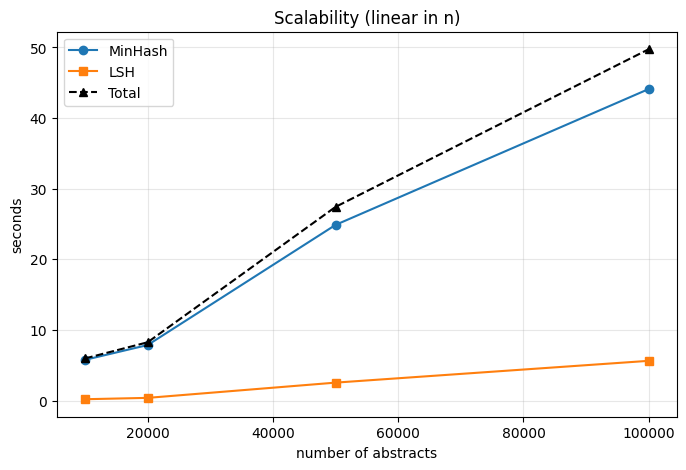

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(bench["n"], bench["minhash_s"], "o-", label="MinHash")
plt.plot(bench["n"], bench["lsh_s"], "s-", label="LSH")
plt.plot(bench["n"], bench["total_s"], "^--", color="black", label="Total")
plt.xlabel("number of abstracts")
plt.ylabel("seconds")
plt.title("Scalability (linear in n)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# We create a "Scalability" Dataset adding the execution time and RAM usage of the full_dataset (or of the subsample applied)

# the actual run size was already computed above reuse those numbers
rss_full = _PROC.memory_info().rss / 1e9 if _PROC else float("nan")
full_row = pd.DataFrame([{
    "n": len(df), "minhash_s": t_minhash_full, "lsh_s": t_lsh_full,
    "total_s": t_minhash_full + t_lsh_full, "candidates": len(candidate_pairs), "rss_GB": rss_full,
}])

bench = pd.concat([bench, full_row], ignore_index=True)
print("="*10, "Scalability dataset", "="*10)
bench

========== Scalability dataset ==========


,n,minhash_s,lsh_s,total_s,candidates,rss_GB
0,10000,5.776305,0.199390,5.975695,30,4.506116
1,20000,7.874650,0.390986,8.265636,70,4.510118
2,50000,24.882892,2.549670,27.432562,296,4.522131
3,100000,44.117931,5.635441,49.753372,758,4.542140
4,3064847,1702.391784,156.109382,1858.501167,19875,4.502786
